In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Make plots show inside the notebook
%matplotlib inline

In [3]:
from google.colab import files
uploaded = files.upload()   # when the file picker opens, select ALL 4 csv files together

Saving salesdaily.csv to salesdaily.csv
Saving saleshourly.csv to saleshourly.csv
Saving salesmonthly.csv to salesmonthly.csv
Saving salesweekly.csv to salesweekly.csv


In [4]:
import pandas as pd

dfs = []

for fname in uploaded.keys():
    print("Reading:", fname)
    temp_df = pd.read_csv(fname)
    dfs.append(temp_df)

# Combine them into a single DataFrame
df = pd.concat(dfs, ignore_index=True)

# Look at the first few rows
df.head()

Reading: salesdaily.csv
Reading: saleshourly.csv
Reading: salesmonthly.csv
Reading: salesweekly.csv


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,01-02-2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014.0,1.0,248.0,Thursday
1,01-03-2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014.0,1.0,276.0,Friday
2,01-04-2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014.0,1.0,276.0,Saturday
3,01-05-2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014.0,1.0,276.0,Sunday
4,01-06-2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014.0,1.0,276.0,Monday


In [7]:
df = df.rename(columns={
    'datum': 'date',          # change 'Date' to your actual date column
    'ATC': 'ATC',            # or 'ATC_code' -> 'ATC'
    'Drug': 'drug',          # change to your drug/brand name column
    'Quantity': 'quantity'   # change to your quantity column
})

# Convert date column to datetime, handling mixed formats
df['date'] = pd.to_datetime(df['date'], format='mixed')

df.head()

,date,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014.0,1.0,248.0,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014.0,1.0,276.0,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014.0,1.0,276.0,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014.0,1.0,276.0,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014.0,1.0,276.0,Monday


In [11]:
# Identify columns that represent ATC codes and their quantities
atc_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Identify other columns to keep as identifier variables during melting
id_vars = [col for col in df.columns if col not in atc_columns]

# Melt the DataFrame to transform it into a long format
df_melted = df.melt(id_vars=id_vars,
                     value_vars=atc_columns,
                     var_name='ATC', # New column for ATC codes
                     value_name='quantity') # New column for quantities

# Now, group by 'ATC' and sum the 'quantity' for each ATC code
total_by_atc = df_melted.groupby('ATC')['quantity'].sum().sort_values(ascending=False)
print(total_by_atc)

ATC
N02BE    251494.153125
N05B      74285.512500
R03       46563.718750
M01AB     42302.251250
M01AE     32769.855938
N02BA     32568.086000
R06       24389.832500
N05C       4998.875000
Name: quantity, dtype: float64


In [13]:
total_by_drug = df_melted.groupby('ATC')['quantity'].sum().sort_values(ascending=False)
print(total_by_drug.head(10))  # top 10 drugs

ATC
N02BE    251494.153125
N05B      74285.512500
R03       46563.718750
M01AB     42302.251250
M01AE     32769.855938
N02BA     32568.086000
R06       24389.832500
N05C       4998.875000
Name: quantity, dtype: float64


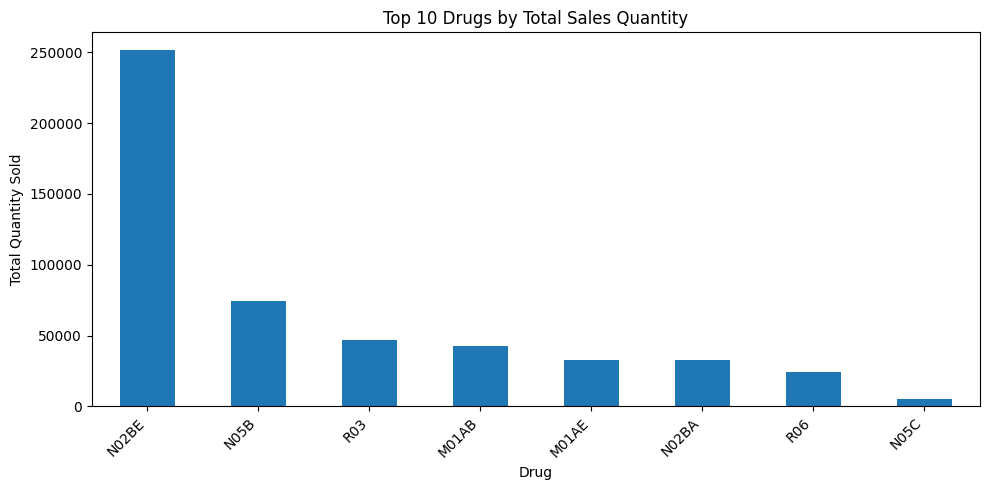

In [14]:
top10 = total_by_drug.head(10)

plt.figure(figsize=(10, 5))
top10.plot(kind='bar')
plt.title('Top 10 Drugs by Total Sales Quantity')
plt.ylabel('Total Quantity Sold')
plt.xlabel('Drug')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
def top3_for_month(year, month):
    # filter rows for that year and month
    mask = (df['date'].dt.year == year) & (df['date'].dt.month == month)
    df_month = df[mask]

    # group by drug, sum quantities, sort descending, take top 3
    return df_month.groupby('drug')['quantity'].sum().sort_values(ascending=False).head(3)

In [17]:
def top3_for_month(year, month):
    # filter rows for that year and month from df_melted
    mask = (df_melted['date'].dt.year == year) & (df_melted['date'].dt.month == month)
    df_month_melted = df_melted[mask]

    # group by ATC, sum quantities, sort descending, take top 3
    return df_month_melted.groupby('ATC')['quantity'].sum().sort_values(ascending=False).head(3)

print("Top 3 drugs in January 2015:")
print(top3_for_month(2015, 1))
print()

print("Top 3 drugs in July 2016:")
print(top3_for_month(2016, 7))
print()

print("Top 3 drugs in September 2017:")
print(top3_for_month(2017, 9))

Top 3 drugs in January 2015:
ATC
N02BE    4145.34
N05B     1795.00
R03       686.00
Name: quantity, dtype: float64

Top 3 drugs in July 2016:
ATC
N02BE    2688.448
N05B     1007.500
M01AB     805.885
Name: quantity, dtype: float64

Top 3 drugs in September 2017:
ATC
N02BE    3271.05
N05B      882.00
M01AB     576.00
Name: quantity, dtype: float64


In [19]:
mask_2017 = df_melted['date'].dt.year == 2017
df_melted_2017 = df_melted[mask_2017]

total_by_drug_2017 = df_melted_2017.groupby('ATC')['quantity'].sum().sort_values(ascending=False)
print(total_by_drug_2017.head(10))  # see top 10

print("\nDrug with highest sales in 2017:")
print(total_by_drug_2017.head(1))

ATC
N02BE    35972.557500
N05B      9789.625000
R03       7461.843750
M01AB     7239.301250
M01AE     5415.129000
N02BA     4986.004167
R06       3890.190000
N05C       688.000000
Name: quantity, dtype: float64

Drug with highest sales in 2017:
ATC
N02BE    35972.5575
Name: quantity, dtype: float64


In [21]:
# Step 1: daily totals per category
daily_by_atc = df_melted.groupby(
    ['ATC', df_melted['date'].dt.date]  # ATC and calendar date (no time)
)['quantity'].sum().reset_index(name='daily_quantity')

# Step 2: average daily quantity per ATC category
avg_daily_by_atc = daily_by_atc.groupby('ATC')['daily_quantity'].mean().sort_values(ascending=False)

print("Average daily sales (quantity) by ATC category:")
print(avg_daily_by_atc)

Average daily sales (quantity) by ATC category:
ATC
N02BE    119.304627
N05B      35.239807
R03       22.089051
M01AB     20.067482
M01AE     15.545472
N02BA     15.449756
R06       11.570129
N05C       2.371383
Name: daily_quantity, dtype: float64


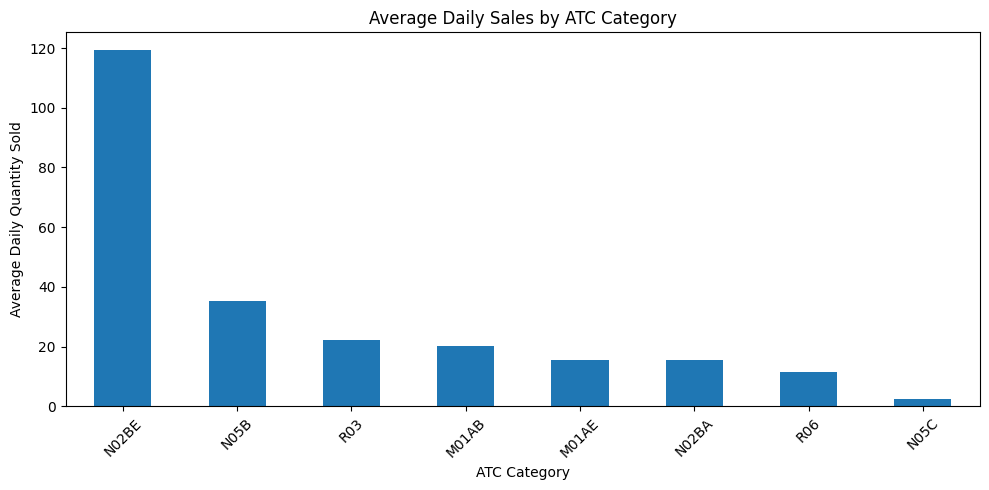

In [22]:
plt.figure(figsize=(10, 5))
avg_daily_by_atc.plot(kind='bar')
plt.title('Average Daily Sales by ATC Category')
plt.ylabel('Average Daily Quantity Sold')
plt.xlabel('ATC Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Filter respiratory drugs from df_melted
r03 = df_melted[df_melted['ATC'] == 'R03']

# Group by month (1–12) and sum quantity
r03_monthly = r03.groupby(r03['date'].dt.month)['quantity'].sum()

print("Total R03 quantity by month (1 = January, ..., 12 = December):")
print(r03_monthly)

Total R03 quantity by month (1 = January, ..., 12 = December):
date
1     4827.21875
2     4674.75000
3     4795.00000
4     4216.62500
5     3764.87500
6     3151.00000
7     2223.00000
8     2299.00000
9     3122.25000
10    4785.00000
11    3793.00000
12    4912.00000
Name: quantity, dtype: float64


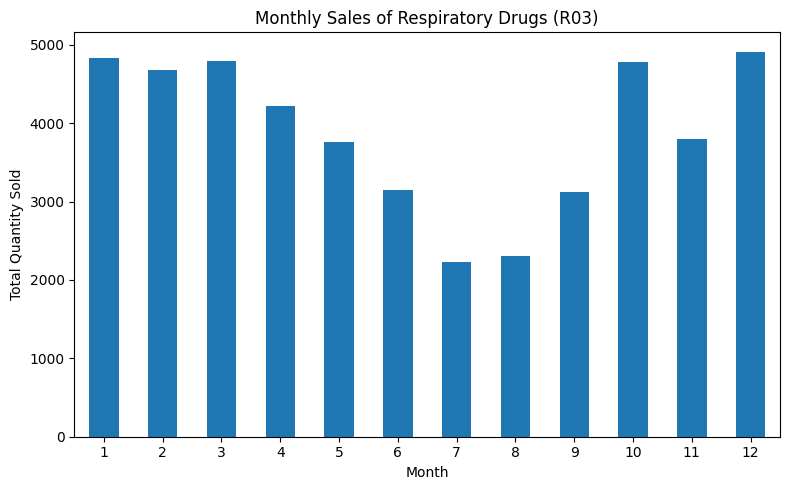

In [25]:
plt.figure(figsize=(8, 5))
r03_monthly.plot(kind='bar')
plt.title('Monthly Sales of Respiratory Drugs (R03)')
plt.ylabel('Total Quantity Sold')
plt.xlabel('Month')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()